# Choosing a representative subset of NL2RepoBench

NL2RepoBench has **104 tasks**. Running one configuration over all of them, five
times each, is 520 trials; at roughly six minutes of wall clock and one long
model call per trial that is a day of compute and a substantial API bill *per
arm of the comparison*. With five arms (Self-Collaboration, CodeTeam, CodeS,
Single-Shot, Terminus) the full design is 2 600 trials.

This notebook selects a **smaller subset that preserves the benchmark's
composition**, so that a comparison run on the subset means the same thing as a
comparison run on all 104 tasks — only cheaper. Everything a reader needs in
order to check that claim is here: where each number comes from, the exact
selection rule, the figures that show the subset matches the whole, and the
`task_names:` block the platform will actually run.

**The one thing this notebook must not do** is let the outcome influence the
selection. Every input used below is *published task metadata* — difficulty
label, hidden-test count, specification length. No reward, score or result from
any run enters the selection. The existing full-benchmark run is used only
*afterwards*, as an independent check (last section).

---

**Outputs written by this notebook**

| Path | What it is |
| --- | --- |
| `benchmarks/nl2repobench/task_metadata.csv` | the 104-task metadata table (cached from pinned upstream sources) |
| `benchmarks/nl2repobench/subset.csv` | the selected tasks, with the metadata that justified them |
| `configs/nl2repobench-subset-single-shot.yaml` | a runnable config: the full-run config, narrowed to the subset |
| `docs/figures/*.png` | the figures below, for the write-up |

## 1. Parameters

Every knob is in this one cell, so that "what did you actually run?" has a
single answer. Note what is *not* here: a hand-picked seed. The seed is found by
a declared rule (§5) rather than chosen, which is the difference between a
balanced sample and a flattering one.

In [1]:
from __future__ import annotations

import io
import json
import math
import random
import urllib.request
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# --- selection parameters ----------------------------------------------------
SUBSET_SIZE = 30           # tasks to run instead of 104

# The balance a draw must achieve to be accepted, as the worst standardised mean
# difference across the size proxies of §4 (measured on a log scale — see §5).
# 0.10 is the conventional threshold for "balanced"; this asks for twice that.
BALANCE_THRESHOLD = 0.05
# Seeds are tried in this order and the FIRST one meeting the threshold is used.
# A mechanical search with a declared bar, rather than a chosen number.
SEED_SEARCH_LIMIT = 1000

# --- provenance -------------------------------------------------------------
# The upstream commit every published number below is read from. Pinning the
# commit rather than a branch is what makes this notebook re-runnable: `main`
# moves, this does not.
NL2REPO_REPO = "multimodal-art-projection/NL2RepoBench"
NL2REPO_SHA = "781a1da1ee41fb8edb0bed22f586d69111610edf"

# The Harbor dataset digest the platform runs. This must match `benchmark.ref`
# in the configurations under `configs/`, or the subset names tasks from a
# different version of the benchmark than the one being run.
HARBOR_DATASET = "nl2repobench/nl2repobench"
HARBOR_REF = "sha256:b0d58e327ee30a6e6584bd4843a53db52a3442e230630369da095ec564542712"

# Re-download the upstream metadata instead of reading the cached CSV. Off by
# default so the notebook runs offline and reproduces byte-for-byte.
REFRESH_METADATA = False

# --- paths ------------------------------------------------------------------
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
METADATA_CSV = REPO / "benchmarks" / "nl2repobench" / "task_metadata.csv"
SUBSET_CSV = REPO / "benchmarks" / "nl2repobench" / "subset.csv"
SUBSET_CONFIG = REPO / "configs" / "nl2repobench-subset-single-shot.yaml"
FIGURES = REPO / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Harbor's local task cache, used only for an integrity cross-check (§4).
HARBOR_CACHE = Path.home() / ".cache" / "harbor" / "tasks" / "packages" / "nl2repobench"

LEVELS = ["Easy", "Medium", "Hard"]

# The paper's definition of the difficulty labels, in lines of code.
LOC_BANDS = {
    "Easy": (0, 1500),
    "Medium": (1500, 4000),
    "Hard": (4000, None),   # open-ended
}

print(f"repo root         : {REPO}")
print(f"subset size       : {SUBSET_SIZE} of 104 tasks ({SUBSET_SIZE / 104:.1%})")
print(f"balance threshold : worst |SMD| ≤ {BALANCE_THRESHOLD}")
print(f"benchmark ref     : {HARBOR_REF}")

repo root         : C:\Code\EvaluationPlatform
subset size       : 30 of 104 tasks (28.8%)
balance threshold : worst |SMD| ≤ 0.05
benchmark ref     : sha256:b0d58e327ee30a6e6584bd4843a53db52a3442e230630369da095ec564542712


### Plotting conventions

Colour carries one meaning throughout: **the difficulty band**, on a single-hue
ramp that runs light (Easy) to dark (Hard), because difficulty is *ordered* and
an ordered variable does not get arbitrary hues. Full benchmark versus subset is
carried by *fill treatment* rather than by a second colour — hollow for the
whole benchmark, solid for the subset — and every bar is direct-labelled, so no
reading of these figures depends on telling two colours apart.

In [2]:
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
SURFACE = "#fcfcfb"

# Ordinal ramp, light -> dark, one hue. Steps chosen from the blue ramp so the
# lightest still clears 2:1 against the surface.
BAND_COLOR = {"Easy": "#86b6ef", "Medium": "#256abf", "Hard": "#0d366b"}

# Population vs sample, where the difficulty ramp is not in play: the whole
# benchmark is context (grey), the subset is the one thing being shown (blue).
FULL_COLOR = "#898781"
SUBSET_COLOR = "#2a78d6"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 9,
    "text.color": INK,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "legend.frameon": False,
    "legend.fontsize": 8.5,
    "lines.linewidth": 2,
})


def tidy(ax, *, grid_axis="y"):
    """Recessive chrome: no box, one axis of hairline grid."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.grid(axis=grid_axis, which="major")
    ax.grid(axis={"y": "x", "x": "y"}[grid_axis], which="major", visible=False)
    ax.tick_params(length=0)
    return ax


def save(fig, name):
    path = FIGURES / f"{name}.png"
    fig.savefig(path)
    print(f"wrote {path.relative_to(REPO)}")

## 2. The data, and where every column comes from

Four columns describe each task. Two are published facts, two are measurements
of published files. None of them is an outcome.

| Column | Source | What it is |
| --- | --- | --- |
| `task` | directory name under `test_files/` | the task identifier, identical to the Harbor task name after the `nl2repobench/` prefix |
| `difficulty` | [`test_files/task_difficulty.csv`](https://github.com/multimodal-art-projection/NL2RepoBench/blob/main/test_files/task_difficulty.csv) | `Easy` / `Medium` / `Hard`, the label the paper defines by lines of code |
| `n_hidden_tests` | `test_files/<task>/test_case_count.txt` | how many reference tests the task is scored against — **the denominator of the reward** |
| `spec_words` | `test_files/<task>/start.md` | length of the natural-language specification the agent is given |

`start.md` is not a separate document: it is byte-for-byte the `instruction.md`
that Harbor ships inside each task package and hands to the agent, so measuring
it upstream measures exactly the prompt the platform sends.

Both measured columns are read at the pinned commit `781a1da`. Set
`REFRESH_METADATA = True` above to re-fetch them; otherwise the cached CSV is
used and the notebook needs no network.

In [3]:
def fetch_upstream_metadata() -> pd.DataFrame:
    """Read the 104 tasks and their published metadata from the pinned commit."""
    raw = f"https://raw.githubusercontent.com/{NL2REPO_REPO}/{NL2REPO_SHA}"

    def get(path: str) -> str:
        with urllib.request.urlopen(f"{raw}/{path}", timeout=60) as response:
            return response.read().decode("utf-8", errors="replace")

    levels = pd.read_csv(io.StringIO(get("test_files/task_difficulty.csv")))
    api = (
        f"https://api.github.com/repos/{NL2REPO_REPO}/contents/"
        f"test_files?ref={NL2REPO_SHA}"
    )
    with urllib.request.urlopen(api, timeout=60) as response:
        listing = json.load(response)
    tasks = sorted(
        entry["name"] for entry in listing
        if entry["type"] == "dir" and not entry["name"].startswith(".")
    )

    def measure(task: str) -> dict:
        spec = get(f"test_files/{task}/start.md")
        return {
            "task": task,
            "n_hidden_tests": int(get(f"test_files/{task}/test_case_count.txt").strip()),
            "spec_words": len(spec.split()),
            "spec_chars": len(spec),
        }

    with ThreadPoolExecutor(12) as pool:
        measured = pd.DataFrame(list(pool.map(measure, tasks)))

    # The difficulty CSV spells 15 of the 104 task names with different
    # capitalisation from the directories (`Autopep8` vs `autopep8`). The join
    # is therefore case-insensitive; §4 shows what happens when it is not.
    levels["key"] = levels["task-name"].str.lower()
    measured["key"] = measured["task"].str.lower()
    joined = measured.merge(
        levels.rename(columns={"task-name": "difficulty_csv_name", "Level": "difficulty"}),
        on="key", how="left", validate="one_to_one",
    ).drop(columns="key")
    joined.insert(1, "harbor_task", "nl2repobench/" + joined["task"])
    return joined[[
        "task", "harbor_task", "difficulty_csv_name", "difficulty",
        "n_hidden_tests", "spec_words", "spec_chars",
    ]].sort_values("task", key=lambda s: s.str.lower(), ignore_index=True)


if REFRESH_METADATA or not METADATA_CSV.exists():
    tasks = fetch_upstream_metadata()
    METADATA_CSV.parent.mkdir(parents=True, exist_ok=True)
    tasks.to_csv(METADATA_CSV, index=False)
    print(f"fetched from {NL2REPO_SHA[:7]} and cached to {METADATA_CSV.relative_to(REPO)}")
else:
    tasks = pd.read_csv(METADATA_CSV)
    print(f"read cache {METADATA_CSV.relative_to(REPO)} (commit {NL2REPO_SHA[:7]})")

tasks["difficulty"] = pd.Categorical(tasks["difficulty"], categories=LEVELS, ordered=True)

assert len(tasks) == 104, f"expected 104 tasks, got {len(tasks)}"
assert tasks["difficulty"].notna().all(), "some task has no difficulty label"
assert not tasks["task"].duplicated().any()

counts = tasks["difficulty"].value_counts().reindex(LEVELS)
print("\n" + f"{len(tasks)} tasks: "
      + ", ".join(f"{level} {int(n)}" for level, n in counts.items()))
tasks.head()

read cache benchmarks\nl2repobench\task_metadata.csv (commit 781a1da)

104 tasks: Easy 26, Medium 46, Hard 32


,task,harbor_task,difficulty_csv_name,difficulty,n_hidden_tests,spec_words,spec_chars
0,aiofiles,nl2repobench/aiofiles,aiofiles,Medium,211,5829,48890
1,arguably,nl2repobench/arguably,arguably,Medium,70,8340,69032
2,arxiv-mcp-server,nl2repobench/arxiv-mcp-server,arxiv-mcp-server,Easy,23,3431,29673
3,asteval,nl2repobench/asteval,asteval,Medium,227,8111,69309
4,autojump,nl2repobench/autojump,autojump,Medium,23,9334,77548


The counts reproduce the paper exactly — 26 Easy, 46 Medium, 32 Hard — which is
the first check that the right file has been read.

## 3. An integrity check worth knowing about

Each Harbor task package carries its own `[metadata] difficulty` field, and it
would be the convenient thing to filter on — no download, already local. It is
also **wrong for 15 of the 104 tasks**, and wrong in a way that is quiet: those
15 read `Unknown` rather than a level.

The 15 are exactly the tasks whose name is capitalised differently in
`task_difficulty.csv` than in the task directory (`Autopep8`/`autopep8`,
`DBUtils`/`dbutils`, `jusText`/`justext`, …). Whoever packaged the dataset for
Harbor joined the two on an exact string match, and those rows fell through.
Filtering on `task.toml` would therefore drop 15 tasks — 8 of them Hard —
from any difficulty-stratified selection, and silently skew it easy.

This notebook uses `task_difficulty.csv` with a case-insensitive join, which is
why. The cell below re-verifies that claim against whatever task packages are in
the local Harbor cache; it is skipped, not failed, if the cache is empty.

In [4]:
import tomllib

if HARBOR_CACHE.exists():
    packaged = []
    for task_dir in sorted(HARBOR_CACHE.iterdir()):
        digest_dir = next(task_dir.iterdir(), None)
        if digest_dir is None or not (digest_dir / "task.toml").exists():
            continue
        toml = tomllib.loads((digest_dir / "task.toml").read_text(encoding="utf-8"))
        packaged.append({
            "task": task_dir.name,
            "difficulty_task_toml": toml.get("metadata", {}).get("difficulty"),
        })

    check = tasks.merge(pd.DataFrame(packaged), on="task", how="left")
    disagree = check[check["difficulty"].astype(str) != check["difficulty_task_toml"]]

    print(f"cached task packages       : {len(packaged)}")
    print(f"task.toml difficulty counts: {dict(Counter(r['difficulty_task_toml'] for r in packaged))}")
    print(f"disagreements with the CSV : {len(disagree)}\n")
    if len(disagree):
        print(f"of which Hard, per the CSV : {(disagree['difficulty'] == 'Hard').sum()}")
        display(disagree[[
            "task", "difficulty_csv_name", "difficulty", "difficulty_task_toml",
        ]].reset_index(drop=True))
else:
    print(f"no Harbor task cache at {HARBOR_CACHE} — cross-check skipped.")

cached task packages       : 104
task.toml difficulty counts: {'Medium': 43, 'Easy': 23, 'Unknown': 15, 'Hard': 23}
disagreements with the CSV : 15

of which Hard, per the CSV : 9


,task,difficulty_csv_name,difficulty,difficulty_task_toml
0,autopep8,Autopep8,Hard,Unknown
1,box,Box,Medium,Unknown
2,cachier,Cachier,Hard,Unknown
3,cherry,Cherry,Easy,Unknown
4,dbutils,DBUtils,Hard,Unknown
5,deslib,DESlib,Hard,Unknown
6,dictdatabase,DictDataBase,Medium,Unknown
7,justext,jusText,Easy,Unknown
8,more-Itertools,More-Itertools,Hard,Unknown
9,pyautogui,PyAutoGUI,Medium,Unknown


## 4. What "LOC" can and cannot mean here

The paper defines the three labels by the size of the reference repository:

| Label | Lines of code | Tasks |
| --- | --- | --- |
| Easy | ≤ 1 500 | 26 |
| Medium | 1 500 – 4 000 | 46 |
| Hard | ≥ 4 000 | 32 |

**NL2RepoBench does not publish the per-task line count.** The repository ships
the label, not the number behind it: `test_files/<task>/` contains the
specification, the test-case count and the test commands, and nothing else.
So "the distribution of LOC" is knowable at the resolution of these three bands
and no finer, and every LOC figure below is drawn at that resolution. Inventing
a line count per task — by measuring the upstream project as it stands today,
say — would be measuring a different artefact than the one the benchmark was
built from, and is not done here.

What *is* published per task, and does vary continuously, is two things that
should track repository size:

- **`n_hidden_tests`** — the number of reference tests the task is scored
  against. This is the reward's denominator, so it also governs how finely a
  task can score: a task with 2 tests can only return 0, 0.5 or 1.
- **`spec_words`** — the length of the specification the agent is handed, which
  is the description of the repository it has to build.

If those two really do track size, they should correlate with the label — and
they do. That makes them usable as **continuous balance checks**: the subset can
be shown to match the whole benchmark on more than the three-way label alone.

In [5]:
# The two published size proxies, and their log10. Both span three orders of
# magnitude and are strongly right-skewed, so log10 is the scale on which their
# balance is judged in §5 and §8; the raw scale is reported alongside it.
PROXIES = ["n_hidden_tests", "spec_words"]
PROXY_LABEL = {
    "n_hidden_tests": "hidden reference tests per task",
    "spec_words": "specification length (words)",
}
for column in PROXIES:
    tasks[f"log_{column}"] = np.log10(tasks[column])

summary = (
    tasks.groupby("difficulty", observed=True)
    .agg(
        tasks=("task", "size"),
        tests_median=("n_hidden_tests", "median"),
        tests_min=("n_hidden_tests", "min"),
        tests_max=("n_hidden_tests", "max"),
        spec_words_median=("spec_words", "median"),
    )
    .assign(share=lambda d: (d["tasks"] / d["tasks"].sum()).map("{:.1%}".format))
)

ordinal = tasks["difficulty"].cat.codes
print("Spearman correlation with the difficulty label")
for column in PROXIES:
    rho, p = stats.spearmanr(ordinal, tasks[column])
    print(f"  {column:15s} rho = {rho:+.3f}   (p = {p:.2g})")
print()
summary

Spearman correlation with the difficulty label
  n_hidden_tests  rho = +0.638   (p = 3.4e-13)
  spec_words      rho = +0.711   (p = 2.7e-17)



,tasks,tests_median,tests_min,tests_max,spec_words_median,share
difficulty,,,,,,
Easy,26,37.5,2,217,3689.0,25.0%
Medium,46,149.5,23,614,5937.0,44.2%
Hard,32,349.0,36,2182,15771.0,30.8%


Both proxies rise monotonically across the bands and correlate with the label at
ρ ≈ 0.6–0.7. They are not lines of code, and are not presented as such — they
are independent, published, continuously-valued evidence about task size, which
is enough to test whether a subset is skewed within a band.

## 5. The selection rule

**Stratified systematic sampling, proportionally allocated, accepted on a
declared balance constraint.** In full:

1. **Strata** are the three published difficulty levels. Nothing else defines
   them, so anyone can reconstruct them from the upstream CSV.
2. **Allocation is proportional**: stratum *h* contributes
   `round(N_h × n / 104)` tasks, with the rounding done by the largest-remainder
   method so the parts sum to exactly *n*. This is what makes the subset's
   difficulty mix match the benchmark's *by construction* rather than by luck.
3. **Within a stratum**, tasks are sorted by size proxy — `n_hidden_tests`, ties
   broken by `spec_words` then name — and a **systematic sample** is drawn: a
   random start `u ~ U(0, N_h/n_h)`, then every `N_h/n_h`-th task from there.
4. **A draw is accepted** only if its worst |SMD| across the two size proxies is
   at most `BALANCE_THRESHOLD = 0.05`. Seeds are tried in the order
   0, 1, 2, … and the **first** one that clears the bar is used.

Four choices in there deserve their justification stated rather than assumed.

**Why proportional and not optimal allocation.** Neyman allocation would put
more tasks where the outcome varies most, and would give a tighter estimate —
but it needs the per-stratum outcome variance, which is only knowable from
results. Using the existing full run to set it would let the outcome choose the
sample, which is the one thing this selection must not do. Proportional
allocation needs nothing but the published stratum sizes.

**Why systematic and not simple random sampling within a stratum.** Both give
every task in stratum *h* the same inclusion probability `n_h/N_h`, so both are
unbiased. But a simple random draw of 13 from 46 can, by luck, take mostly small
tasks; drawing systematically down a size-ordered list cannot — it forces the
sample to span the size range at even spacing. This is standard *implicit
stratification*: the same guarantee, plus a sample that spans size within each
band as well as across bands.

**Why balance is measured on a log scale.** Both proxies span three orders of
magnitude and are strongly right-skewed — hidden-test counts run from 2 to
2 182. On the raw scale a single large task moving in or out of the sample
dominates the mean, so raw-scale SMD measures the tail rather than the
distribution. `log₁₀` is the scale these quantities actually live on; it is also
the axis the distributions are drawn on in §8. Both scales are reported in the
diagnostics table, so nothing is hidden by the choice.

**Why a search does not amount to seed-shopping.** The distinction is whether
the stopping rule is declared in advance or discovered afterwards. Here the
threshold (0.05), the metric (worst |SMD| over the two proxies, log scale) and
the enumeration order (0, 1, 2, …) are all fixed before any draw is inspected,
and the search stops at the first acceptance — there is no choosing among
candidates that pass. This is the same idea as *balanced sampling* in survey
practice: draw at random, subject to a constraint the design declares. §9 plots
the balance of every seed in the search range with the accepted region marked,
so the size of what was searched over is visible rather than asserted.

The honest cost of the constraint is that inclusion probabilities are uniform
*conditional on the constraint* rather than unconditionally. At this scale that
is a much better trade than the alternative: without it, the typical draw at
n = 30 lands right at the conventional 0.10 threshold, and which side of it you
end up on is luck.

In [6]:
def allocate(n: int, stratum_sizes: dict[str, int]) -> dict[str, int]:
    """Proportional allocation of `n` across strata, largest-remainder rounding."""
    total = sum(stratum_sizes.values())
    exact = {level: size * n / total for level, size in stratum_sizes.items()}
    alloc = {level: int(math.floor(value)) for level, value in exact.items()}
    # Hand out the seats lost to flooring, largest fractional part first.
    remainder = n - sum(alloc.values())
    order = sorted(stratum_sizes, key=lambda level: (-(exact[level] - alloc[level]),
                                                     LEVELS.index(level)))
    for level in order[:remainder]:
        alloc[level] += 1
    return alloc


def select(frame: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    """Stratified systematic sample, size-ordered within each stratum."""
    sizes = {level: int((frame["difficulty"] == level).sum()) for level in LEVELS}
    alloc = allocate(n, sizes)
    rng = random.Random(seed)

    chosen = []
    for level in LEVELS:
        pool = (
            frame[frame["difficulty"] == level]
            .sort_values(["n_hidden_tests", "spec_words", "task"], ignore_index=True)
        )
        n_h, N_h = alloc[level], len(pool)
        step = N_h / n_h
        start = rng.uniform(0, step)
        positions = [min(N_h - 1, int(math.floor(start + k * step))) for k in range(n_h)]
        assert len(set(positions)) == n_h, "systematic sample drew a task twice"
        chosen.append(pool.iloc[positions])

    return pd.concat(chosen, ignore_index=True).sort_values(
        "task", key=lambda s: s.str.lower(), ignore_index=True
    )


def smd(population: np.ndarray, sample: np.ndarray) -> float:
    """Standardised mean difference: the gap in pooled standard deviations."""
    pooled = math.sqrt((population.std(ddof=0) ** 2 + sample.std(ddof=0) ** 2) / 2)
    return (sample.mean() - population.mean()) / pooled if pooled else 0.0


def balance_of(frame: pd.DataFrame, sample: pd.DataFrame) -> float:
    """The worst |SMD| across the log-scaled size proxies. Lower is better."""
    return max(
        abs(smd(frame[f"log_{column}"].to_numpy(float),
                sample[f"log_{column}"].to_numpy(float)))
        for column in PROXIES
    )


def find_seed(frame: pd.DataFrame, n: int, threshold: float, limit: int):
    """The first seed whose draw meets the balance constraint, and the search."""
    trail = []
    for seed in range(limit):
        trail.append(balance_of(frame, select(frame, n, seed)))
        if trail[-1] <= threshold:
            return seed, np.array(trail)
    raise RuntimeError(
        f"no seed under {limit} reached |SMD| <= {threshold} at n={n}. "
        "Raise SEED_SEARCH_LIMIT, relax BALANCE_THRESHOLD, or take more tasks."
    )


sizes = {level: int((tasks["difficulty"] == level).sum()) for level in LEVELS}

print(f"Proportional allocation at several subset sizes "
      f"(SUBSET_SIZE = {SUBSET_SIZE} is what this run uses)\n")
rows = []
for n in (20, 26, 30, 36, 40, 52, 104):
    alloc = allocate(n, sizes)
    rows.append({
        "n": n,
        "Easy": alloc["Easy"], "Medium": alloc["Medium"], "Hard": alloc["Hard"],
        "Easy %": alloc["Easy"] / n, "Medium %": alloc["Medium"] / n, "Hard %": alloc["Hard"] / n,
        "of benchmark": n / 104,
    })
allocation_table = pd.DataFrame(rows).set_index("n")
allocation_table.style.format({
    "Easy %": "{:.1%}", "Medium %": "{:.1%}", "Hard %": "{:.1%}", "of benchmark": "{:.1%}",
})

Proportional allocation at several subset sizes (SUBSET_SIZE = 30 is what this run uses)



,Easy,Medium,Hard,Easy %,Medium %,Hard %,of benchmark
n,,,,,,,
20,5,9,6,25.0%,45.0%,30.0%,19.2%
26,7,11,8,26.9%,42.3%,30.8%,25.0%
30,8,13,9,26.7%,43.3%,30.0%,28.8%
36,9,16,11,25.0%,44.4%,30.6%,34.6%
40,10,18,12,25.0%,45.0%,30.0%,38.5%
52,13,23,16,25.0%,44.2%,30.8%,50.0%
104,26,46,32,25.0%,44.2%,30.8%,100.0%


The benchmark's own mix is 25.0 / 44.2 / 30.8 %. Only `n = 52` (and `n = 104`)
can reproduce it exactly — the smallest subset for which all three proportional
shares are whole numbers is half the benchmark, because 46/104 only clears its
denominator at multiples of 52. Every smaller size therefore carries a rounding
error of a percentage point or two, which the table makes visible.

`n = 30` is the default here: it is 28.8 % of the benchmark — a **3.5×**
reduction in trials, from 520 to 150 for a five-repeat run — at a mix of
26.7 / 43.3 / 30.0 %, within 1.7 points of the benchmark's on every band. Change
`SUBSET_SIZE` in §1 to move along that trade-off; §10 quantifies what it costs
in precision.

In [7]:
SEED, search_trail = find_seed(tasks, SUBSET_SIZE, BALANCE_THRESHOLD, SEED_SEARCH_LIMIT)

subset = select(tasks, SUBSET_SIZE, SEED)
alloc = allocate(SUBSET_SIZE, sizes)

print(f"Seeds tried before acceptance : {len(search_trail) - 1}")
print(f"Accepted seed                 : {SEED}")
print(f"  worst |SMD| (log scale)     : {search_trail[-1]:.4f}  "
      f"(threshold {BALANCE_THRESHOLD})")
print(f"Selected {len(subset)} of {len(tasks)} tasks\n")

comparison = pd.DataFrame({
    "benchmark n": pd.Series(sizes),
    "benchmark %": pd.Series(sizes) / 104,
    "subset n": pd.Series(alloc),
    "subset %": pd.Series(alloc) / SUBSET_SIZE,
}).reindex(LEVELS)
comparison["difference"] = comparison["subset %"] - comparison["benchmark %"]
comparison.style.format({
    "benchmark %": "{:.1%}", "subset %": "{:.1%}", "difference": "{:+.1%}",
})

Seeds tried before acceptance : 0
Accepted seed                 : 0
  worst |SMD| (log scale)     : 0.0372  (threshold 0.05)
Selected 30 of 104 tasks



,benchmark n,benchmark %,subset n,subset %,difference
Easy,26,25.0%,8,26.7%,+1.7%
Medium,46,44.2%,13,43.3%,-0.9%
Hard,32,30.8%,9,30.0%,-0.8%


## 6. Figure 1 — the difficulty mix is preserved

The question this figure answers is *"is the subset the same shape as the
benchmark?"*, so it is drawn in proportions rather than counts: two bars
normalised to 100 %, one per set. If the segments line up, the mix matches.
Counts are labelled inside the segments so the absolute numbers are not lost.

wrote docs\figures\subset-difficulty-composition.png


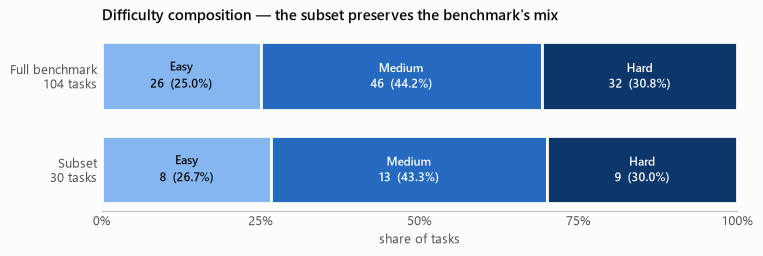

In [8]:
fig, ax = plt.subplots(figsize=(8.2, 2.3))

sets = [
    ("Full benchmark\n104 tasks", sizes, 104),
    (f"Subset\n{SUBSET_SIZE} tasks", alloc, SUBSET_SIZE),
]

for row, (label, counts, total) in enumerate(sets):
    left = 0.0
    for level in LEVELS:
        width = 100 * counts[level] / total
        ax.barh(
            row, width, left=left, height=0.72,
            color=BAND_COLOR[level],
            edgecolor=SURFACE, linewidth=2,          # 2px surface gap between segments
        )
        ax.text(
            left + width / 2, row,
            f"{level}\n{counts[level]}  ({width:.1f}%)",
            ha="center", va="center", fontsize=8.5, linespacing=1.5,
            color="#ffffff" if level != "Easy" else INK, fontweight="semibold",
        )
        left += width

ax.set_yticks(range(len(sets)), [label for label, _, _ in sets], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 25), [f"{v}%" for v in range(0, 101, 25)])
ax.set_xlabel("share of tasks")
ax.set_title("Difficulty composition — the subset preserves the benchmark's mix")
tidy(ax, grid_axis="x")
ax.spines["left"].set_visible(False)

save(fig, "subset-difficulty-composition")
plt.show()

## 7. Figure 2 — the same thing on the LOC axis

Figure 1 in the paper's own terms. The bands are the LOC ranges the labels are
defined by; the bars are how many tasks each set puts in each band. The subset's
bar is drawn *inside* the benchmark's, because that is the actual relationship —
the subset is not a second sample to compare against, it is a part of the whole.

The Hard band is open-ended by definition (≥ 4 000 LOC), which the axis label
says rather than the geometry pretending otherwise.

wrote docs\figures\subset-loc-bands.png


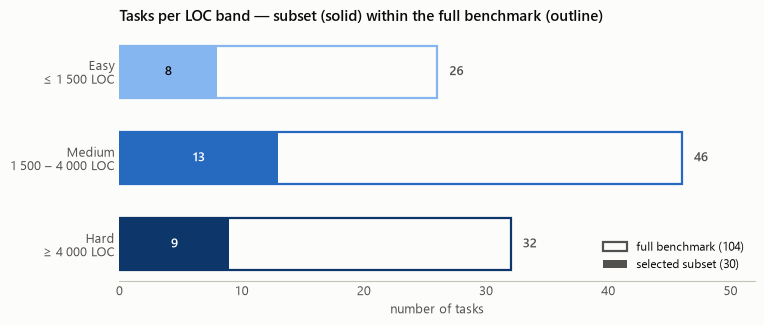

In [9]:
fig, ax = plt.subplots(figsize=(8.2, 3.2))

def band_label(level):
    """The LOC range a difficulty label stands for, per the paper's definition."""
    low, high = LOC_BANDS[level]
    thin = lambda v: f"{v:,}".replace(",", " ")
    if high is None:
        return f"≥ {thin(low)} LOC"
    if low == 0:
        return f"≤ {thin(high)} LOC"
    return f"{thin(low)} – {thin(high)} LOC"
y = np.arange(len(LEVELS))

for i, level in enumerate(LEVELS):
    colour = BAND_COLOR[level]
    ax.barh(i, sizes[level], height=0.60, facecolor="none",
            edgecolor=colour, linewidth=1.6, zorder=2)
    ax.barh(i, alloc[level], height=0.60, color=colour, zorder=3)
    ax.text(alloc[level] / 2, i, str(alloc[level]), ha="center", va="center",
            color="#ffffff" if level != "Easy" else INK, fontsize=9, fontweight="semibold", zorder=4)
    ax.text(sizes[level] + 1.0, i, str(sizes[level]),
            va="center", fontsize=9, color=INK_2, fontweight="semibold")

ax.set_yticks(y, [f"{level}\n{band_label(level)}" for level in LEVELS], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 52)
ax.set_xlabel("number of tasks")
ax.set_title("Tasks per LOC band — subset (solid) within the full benchmark (outline)")
tidy(ax, grid_axis="x")
ax.spines["left"].set_visible(False)

handles = [
    mpl.patches.Patch(facecolor="none", edgecolor=INK_2, linewidth=1.6, label="full benchmark (104)"),
    mpl.patches.Patch(facecolor=INK_2, label=f"selected subset ({SUBSET_SIZE})"),
]
ax.legend(handles=handles, loc="lower right", ncols=1)

save(fig, "subset-loc-bands")
plt.show()

Between them these two figures are the whole claim at the resolution the
published data supports: the subset holds the same proportion of each LOC band,
and it holds enough of each band that no band is represented by a token task.
The next figure asks the harder question — whether the tasks *within* each band
are typical of it.

## 8. Figure 3 — balance on the continuous size proxies

Matching the three-way label is necessary but not sufficient. A subset could
hold exactly 9 Hard tasks and still be unrepresentative if those 9 were the nine
*smallest* Hard tasks. So the two continuous proxies from §4 are compared
between the whole benchmark and the subset, as empirical distribution functions
— the whole distribution rather than just its mean.

Three statistics accompany the curves:

- **SMD (log)** — the standardised mean difference on `log₁₀`, which is the
  quantity the selection constraint of §5 was applied to, and the one to read
  first. |SMD| < 0.1 is the conventional threshold for "balanced" in the
  matching literature; the constraint here asked for 0.05.
- **SMD (raw)** — the same on the untransformed scale, reported so that the
  choice of scale is visible rather than load-bearing.
- **Kolmogorov–Smirnov** — the largest vertical gap between the two curves,
  testing the distributions as wholes rather than their means. A *large* p-value
  is the good outcome here: no detectable difference. (The two samples are
  nested, not independent, so this is a descriptive effect size rather than a
  hypothesis test with a clean null.)

wrote docs\figures\subset-size-proxy-balance.png


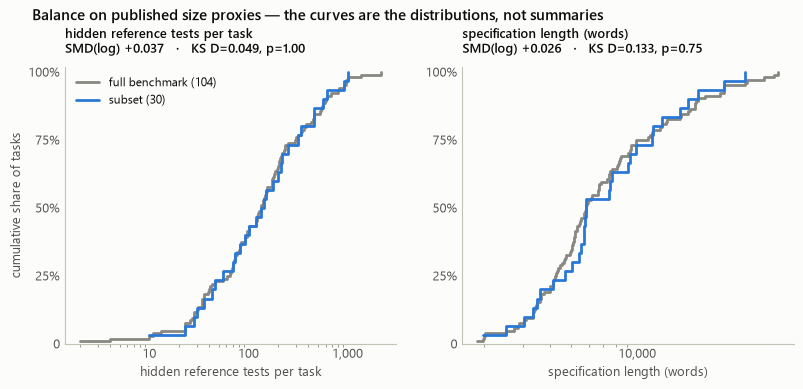

,full median,subset median,full mean,subset mean,SMD (log),SMD (raw),KS D,KS p
proxy,,,,,,,,
n_hidden_tests,133,139,246.5,232.4,+0.037,-0.049,0.049,1.000
spec_words,"5,834","5,834","9,241.8","8,887.7",+0.026,-0.047,0.133,0.749


In [10]:
def ecdf(values: np.ndarray):
    ordered = np.sort(values)
    return ordered, np.arange(1, len(ordered) + 1) / len(ordered)


fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.6))
diagnostics = []

for ax, column in zip(axes, PROXIES):
    label = PROXY_LABEL[column]
    population = tasks[column].to_numpy(dtype=float)
    sample = subset[column].to_numpy(dtype=float)

    for values, colour, name in (
        (population, FULL_COLOR, "full benchmark (104)"),
        (sample, SUBSET_COLOR, f"subset ({SUBSET_SIZE})"),
    ):
        x, y = ecdf(values)
        ax.step(x, y, where="post", color=colour, label=name, solid_capstyle="round")

    ks = stats.ks_2samp(population, sample)
    d_log = smd(tasks[f"log_{column}"].to_numpy(float), subset[f"log_{column}"].to_numpy(float))
    diagnostics.append({
        "proxy": column,
        "full median": np.median(population), "subset median": np.median(sample),
        "full mean": population.mean(), "subset mean": sample.mean(),
        "SMD (log)": d_log, "SMD (raw)": smd(population, sample),
        "KS D": ks.statistic, "KS p": ks.pvalue,
    })

    # Decade ticks only. Matplotlib's default log minor labels overlap badly on
    # a range this wide, and an unreadable axis is worse than a coarse one.
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10))
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.xaxis.set_minor_locator(mpl.ticker.LogLocator(base=10, subs=tuple(np.arange(2, 10) * 0.1)))
    ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())

    ax.set_xlabel(label)
    ax.set_ylim(0, 1.02)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0", "25%", "50%", "75%", "100%"])
    ax.set_title(f"{label}\nSMD(log) {d_log:+.3f}   ·   KS D={ks.statistic:.3f}, p={ks.pvalue:.2f}",
                 fontsize=9.5)
    tidy(ax, grid_axis="y")

axes[0].set_ylabel("cumulative share of tasks")
axes[0].legend(loc="upper left")
fig.suptitle("Balance on published size proxies — the curves are the distributions, not summaries",
             x=0.09, ha="left", fontsize=11, fontweight="semibold", y=1.04)

save(fig, "subset-size-proxy-balance")
plt.show()

pd.DataFrame(diagnostics).set_index("proxy").style.format({
    "full median": "{:,.0f}", "subset median": "{:,.0f}",
    "full mean": "{:,.1f}", "subset mean": "{:,.1f}",
    "SMD (log)": "{:+.3f}", "SMD (raw)": "{:+.3f}", "KS D": "{:.3f}", "KS p": "{:.3f}",
})

Both proxies sit well inside the conventional |SMD| < 0.1 threshold on the scale
the constraint was applied to, and the KS curves are close enough that no
difference is detectable. The subset is not merely holding the right *number* of
Hard tasks — it is holding Hard tasks of typical size.

## 9. Figure 4 — how large a space the constraint searched

The balance in Figure 3 is only meaningful alongside the size of the space it
was found in. Picking the best of a thousand candidates and reporting it as a
random draw would be misleading; taking the first of many that meet a bar
declared in advance is not. The difference is visible only if the whole space is
shown, so **the same selection is run for every seed in the search range and the
balance of all of them is plotted.**

The shaded region is the accepted zone — the constraint from §5. The dashed line
is the conventional |SMD| = 0.10 threshold. The marked seed is the one the rule
stopped at: the leftmost seed *in index order*, which is not the same as the
best one in the picture, and deliberately so.

wrote docs\figures\subset-seed-robustness.png


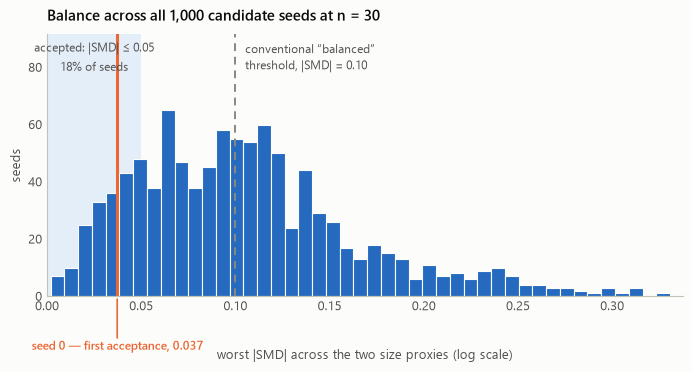

median across seeds              : 0.098
seeds under the convention (0.10): 51.5%
seeds meeting the constraint     : 18.3%  (183 of 1,000)
seeds tried before acceptance    : 0
accepted draw                    : 0.0372


In [11]:
N_SEEDS = SEED_SEARCH_LIMIT

worst = np.array([balance_of(tasks, select(tasks, SUBSET_SIZE, seed))
                  for seed in range(N_SEEDS)])
ours = worst[SEED]

fig, ax = plt.subplots(figsize=(8.2, 3.4))
ax.axvspan(0, BALANCE_THRESHOLD, color=BAND_COLOR["Easy"], alpha=0.20, zorder=0, linewidth=0)
ax.hist(worst, bins=45, color=BAND_COLOR["Medium"], edgecolor=SURFACE, linewidth=0.8, zorder=2)
ax.axvline(0.10, color=MUTED, linewidth=1.4, linestyle=(0, (4, 3)), zorder=4)
ax.axvline(ours, color="#eb6834", linewidth=2.2, zorder=5)

# Headroom above the tallest bar, so the two threshold callouts sit in clear
# space rather than over the data.
top = ax.get_ylim()[1] * 1.34
ax.set_ylim(0, top)

ax.annotate(
    f"accepted: |SMD| ≤ {BALANCE_THRESHOLD}\n"
    f"{(worst <= BALANCE_THRESHOLD).mean():.0%} of seeds",
    xy=(BALANCE_THRESHOLD / 2, top * 0.98), ha="center", va="top",
    fontsize=8.5, color=INK_2, linespacing=1.6, zorder=6)
ax.annotate("conventional “balanced”\nthreshold, |SMD| = 0.10",
            xy=(0.10, top * 0.98), xytext=(7, 0), textcoords="offset points",
            va="top", fontsize=8.5, color=INK_2, linespacing=1.6, zorder=6)
# Below the axis: the marker is the point, and nothing there competes with it.
ax.annotate(f"seed {SEED} — first acceptance, {ours:.3f}",
            xy=(ours, 0), xytext=(0, -32), textcoords="offset points",
            ha="center", va="top", fontsize=8.5, color="#eb6834",
            fontweight="semibold", zorder=6,
            arrowprops=dict(arrowstyle="-", color="#eb6834", linewidth=1.2,
                            shrinkA=0, shrinkB=2))

ax.set_xlim(0, worst.max() * 1.02)
ax.set_xlabel("worst |SMD| across the two size proxies (log scale)", labelpad=26)
ax.set_ylabel("seeds")
ax.set_title(f"Balance across all {N_SEEDS:,} candidate seeds at n = {SUBSET_SIZE}")
tidy(ax, grid_axis="y")

save(fig, "subset-seed-robustness")
plt.show()

print(f"median across seeds              : {np.median(worst):.3f}")
print(f"seeds under the convention (0.10): {(worst <= 0.10).mean():.1%}")
print(f"seeds meeting the constraint     : {(worst <= BALANCE_THRESHOLD).mean():.1%}"
      f"  ({int((worst <= BALANCE_THRESHOLD).sum())} of {N_SEEDS:,})")
print(f"seeds tried before acceptance    : {SEED}")
print(f"accepted draw                    : {ours:.4f}")

Read the shape, not the orange line. Two things are worth taking from it.

**The constraint is doing real work.** At `n = 30` the median unconstrained draw
lands almost exactly on the conventional 0.10 threshold, and roughly half of all
seeds fall on the wrong side of it. Stratification plus size-ordered systematic
sampling gets a draw to "acceptable" on average and no further; without a
constraint, whether a particular subset is well balanced is a coin flip. That is
a fact about `n = 30` rather than about the method — at `n = 52` most seeds clear
0.05 unaided, which is another way of seeing what the smaller subset costs.

**The search was shallow.** Roughly a fifth of all seeds satisfy the constraint,
so acceptance comes quickly — the count of seeds rejected before the accepted one
is printed above, and at these settings it is zero. A rule that had to work
through hundreds of candidates before its first acceptance would be worth
distrusting, because at that point the constraint is isolating a rare
configuration rather than filtering a common one. That is the number to re-check
if `SUBSET_SIZE` or `BALANCE_THRESHOLD` changes.

## 10. What the subset costs in precision

A subset buys compute at the price of a wider confidence interval. That price is
worth stating in the same breath as the saving.

For a proportionally-allocated stratified mean with a finite-population
correction — and the population here is genuinely finite and small, 104 tasks,
so the correction is not a formality:

$$\operatorname{SE}(\bar y_{st}) \;=\; \sqrt{\frac{1}{n}\Bigl(1 - \frac{n}{N}\Bigr)\sum_h W_h S_h^2}$$

$S_h$, the within-stratum spread of per-task reward, is not known before the run.
The curve below is therefore drawn for a plausible range, `S = 0.20 / 0.30 /
0.40` on a reward in [0, 1]; once the full run's per-task rewards are available,
substitute the measured $S_h$ in the cell and the curve becomes exact rather
than indicative.

**The number that actually matters is smaller than this.** Every arm of the
comparison runs the *same* subset, so comparing two methods is a paired
difference over the same tasks, and the task-to-task variance — by far the
largest term — largely cancels:

$$S_D^2 = S_A^2 + S_B^2 - 2\rho S_A S_B \;\approx\; 2S^2(1-\rho)$$

Per-task difficulty is highly correlated between methods (a task nobody can do
is hard for everyone), so ρ is large and $S_D$ is well below $S$. The table
after the figure works that through. A subset is a weaker instrument for
reporting *absolute* scores than for the between-method comparison this platform
exists to make.

wrote docs\figures\subset-precision-vs-size.png


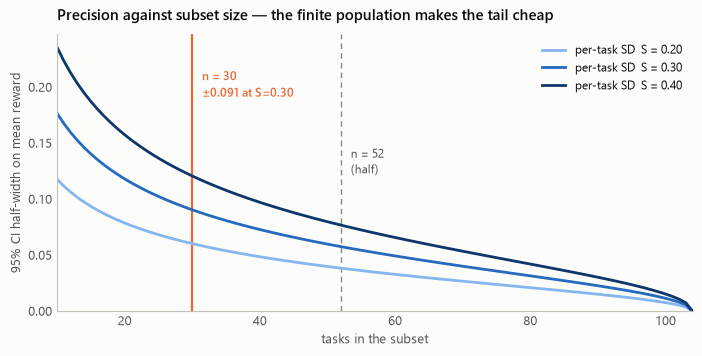

In [12]:
N_POP = 104
n_grid = np.arange(10, 105)


def stratified_se(n, s):
    """SE of the proportionally-allocated stratified mean, with the FPC."""
    return np.sqrt((1 / n) * (1 - n / N_POP)) * s


fig, ax = plt.subplots(figsize=(8.2, 3.6))
ramp = [BAND_COLOR[level] for level in LEVELS]

for colour, s in zip(ramp, (0.20, 0.30, 0.40)):
    ci = 1.96 * stratified_se(n_grid, s)
    # These three never cross and converge on zero at the census, so a legend
    # identifies them without the direct labels colliding with the curves.
    ax.plot(n_grid, ci, color=colour, label=f"per-task SD  S = {s:.2f}")

for n in (SUBSET_SIZE, 52):
    ax.axvline(n, color=MUTED if n != SUBSET_SIZE else "#eb6834",
               linewidth=1.6 if n == SUBSET_SIZE else 1.0,
               linestyle="-" if n == SUBSET_SIZE else (0, (4, 3)), zorder=1)

top = ax.get_ylim()[1]
ax.annotate(f"n = {SUBSET_SIZE}\n\u00b1{1.96 * stratified_se(SUBSET_SIZE, 0.30):.3f} at S=0.30",
            xy=(SUBSET_SIZE, top * 0.88), xytext=(7, 0), textcoords="offset points",
            fontsize=8.5, color="#eb6834", fontweight="semibold", va="top", linespacing=1.5)
ax.annotate("n = 52\n(half)", xy=(52, top * 0.60), xytext=(7, 0),
            textcoords="offset points", fontsize=8.5, color=INK_2, va="top", linespacing=1.5)

ax.set_xlim(10, 104)
ax.set_ylim(0, None)
ax.set_xlabel("tasks in the subset")
ax.set_ylabel("95% CI half-width on mean reward")
ax.set_title("Precision against subset size — the finite population makes the tail cheap")
ax.legend(loc="upper right")
tidy(ax, grid_axis="y")

save(fig, "subset-precision-vs-size")
plt.show()

In [13]:
S = 0.30                       # assumed per-task SD; replace with the measured value
cost_per_trial_minutes = 6     # NL2RepoBench task, wall clock
repeats = 5

rows = []
for n in (20, 26, 30, 36, 40, 52, 104):
    absolute = 1.96 * stratified_se(n, S)
    paired = {rho: 1.96 * stratified_se(n, math.sqrt(2 * S**2 * (1 - rho)))
              for rho in (0.6, 0.8)}
    trials = n * repeats
    rows.append({
        "n": n,
        "trials per arm": trials,
        "hours per arm": trials * cost_per_trial_minutes / 60,
        "saving vs full": 1 - n / 104,
        "±CI, absolute mean": absolute,
        "±CI, paired diff (rho=0.6)": paired[0.6],
        "±CI, paired diff (rho=0.8)": paired[0.8],
    })

pd.DataFrame(rows).set_index("n").style.format({
    "hours per arm": "{:.1f}",
    "saving vs full": "{:.0%}",
    "±CI, absolute mean": "{:.3f}",
    "±CI, paired diff (rho=0.6)": "{:.3f}",
    "±CI, paired diff (rho=0.8)": "{:.3f}",
})

,trials per arm,hours per arm,saving vs full,"±CI, absolute mean","±CI, paired diff (rho=0.6)","±CI, paired diff (rho=0.8)"
n,,,,,,
20,100,10.0,81%,0.118,0.106,0.075
26,130,13.0,75%,0.100,0.089,0.063
30,150,15.0,71%,0.091,0.081,0.057
36,180,18.0,65%,0.079,0.071,0.050
40,200,20.0,62%,0.073,0.065,0.046
52,260,26.0,50%,0.058,0.052,0.036
104,520,52.0,0%,0.000,0.000,0.000


At `n = 30` and an assumed `S = 0.30`, the absolute mean reward carries roughly
±0.09; a paired between-method difference at ρ = 0.8 carries roughly ±0.06 — on
a quarter of the compute. Read the absolute column as "this is why a subset run
should not be reported as *the* NL2RepoBench score", and the paired columns as
"this is why it is fine for ranking the five methods against each other".

## 11. The selected tasks

The list itself, so nothing about the selection has to be taken on trust.

In [14]:
listing = subset[["task", "difficulty", "n_hidden_tests", "spec_words"]].copy()
listing.index = np.arange(1, len(listing) + 1)
listing.columns = ["task", "difficulty", "hidden tests", "spec words"]
listing.style.format({"hidden tests": "{:,}", "spec words": "{:,}"})

,task,difficulty,hidden tests,spec words
1,aiofiles,Medium,211,"5,829"
2,autopep8,Hard,564,"15,665"
3,boto,Hard,"1,014","31,002"
4,cerberus,Hard,249,"7,454"
5,docopt-ng,Medium,614,"5,684"
6,freezegun,Medium,133,"5,408"
7,frontmatter,Easy,55,"5,540"
8,ftfy,Medium,336,"9,304"
9,google-images-download,Easy,30,"2,523"
10,jinja,Hard,911,"18,939"


In [15]:
for level in LEVELS:
    names = subset.loc[subset["difficulty"] == level, "task"].tolist()
    print(f"{level:7s} ({len(names):2d}): {', '.join(names)}\n")

Easy    ( 8): frontmatter, google-images-download, markdownify, pandarallel, pythonprojecttemplate, retrying, sklearn, trimming

Medium  (13): aiofiles, docopt-ng, freezegun, ftfy, plac, pss, pyquery, python-jose, python-pathspec, pytorch-grad-cam, six, uiautomator, voluptuous

Hard    ( 9): autopep8, boto, cerberus, jinja, rich-click, sqlparse, synthetic, tsfresh, wifiphisher



## 12. Writing the run configuration

The selection is only useful if the thing that runs is provably the thing
selected, so the config is generated here rather than transcribed by hand. It is
`configs/nl2repobench-single-shot.yaml` with one block changed — `task_names` —
and in particular the **same** `benchmark.ref` digest, `model` block and `agent`
hyperparameters, because a subset run whose other settings drifted would not be
comparable to the full run it is meant to stand in for.

In [16]:
subset.to_csv(SUBSET_CSV, index=False)
print(f"wrote {SUBSET_CSV.relative_to(REPO)}  ({len(subset)} rows)")

source = (REPO / "configs" / "nl2repobench-single-shot.yaml").read_text(encoding="utf-8")

task_lines = "\n".join(
    f"    - {row.harbor_task}"
    + f"  # {row.difficulty}, {row.n_hidden_tests} tests"
    for row in subset.itertuples()
)

header = f"""\
# Experiment setup: Single-Shot against a representative {SUBSET_SIZE}-task subset
# of NL2RepoBench.
#
# GENERATED by notebooks/nl2repobench-subset-selection.ipynb — edit that
# notebook and re-run it rather than editing this list by hand.
#
# The subset is a stratified systematic sample of the benchmark's 104 tasks:
# strata are the three published difficulty levels, allocation is proportional
# (Easy {alloc['Easy']} / Medium {alloc['Medium']} / Hard {alloc['Hard']}, against the benchmark's {sizes['Easy']} / {sizes['Medium']} / {sizes['Hard']}), and
# within each stratum the sample is drawn systematically down a size-ordered
# list from a random start. The start is the first seed (from 0 upward) whose
# draw holds the worst |SMD| across the two published size proxies to
# {BALANCE_THRESHOLD}, which was seed {SEED}. Selection used only published task metadata —
# difficulty label, hidden-test count, specification length — and no result
# from any run.
#
# Everything below except `name`, `description` and `benchmark.task_names` is
# byte-identical to configs/nl2repobench-single-shot.yaml, including the pinned
# benchmark digest, the model and its routing, and the agent hyperparameters.
# That is what makes a subset run comparable with the full run.
"""

body = source
if body.lstrip().startswith("name:"):
    body = header + "\n" + body
else:  # the source carries its own comment header; replace it
    body = header + "\n" + body[body.index("name:"):]

marker = "  task_names:\n    - nl2repobench/math-verify\n"
assert marker in body, "the source config's task_names block moved — update this cell"
body = body.replace(
    marker,
    f"  # The {SUBSET_SIZE} selected tasks. See benchmarks/nl2repobench/subset.csv for the\n"
    f"  # metadata each was selected on.\n  task_names:\n{task_lines}\n",
)

# A distinct name, so the two runs are distinguishable in `jobs/` and in any
# results table. The name is the one place the configurations *must* differ.
assert body.count("name: nl2repobench-single-shot\n") == 1
body = body.replace("name: nl2repobench-single-shot\n",
                    "name: nl2repobench-subset-single-shot\n")
body = body.replace(
    "  sidecar and are never visible; the reward is the fraction of them that pass.\n",
    "  sidecar and are never visible; the reward is the fraction of them that pass.\n"
    f"  Runs the representative {SUBSET_SIZE}-task subset rather than all 104; the\n"
    "  selection and the evidence for it are in\n"
    "  notebooks/nl2repobench-subset-selection.ipynb.\n",
)

SUBSET_CONFIG.write_text(body, encoding="utf-8")
print(f"wrote {SUBSET_CONFIG.relative_to(REPO)}")
print("\n--- task_names block ---")
print(f"  task_names:\n{task_lines}")

wrote benchmarks\nl2repobench\subset.csv  (30 rows)
wrote configs\nl2repobench-subset-single-shot.yaml

--- task_names block ---
  task_names:
    - nl2repobench/aiofiles  # Medium, 211 tests
    - nl2repobench/autopep8  # Hard, 564 tests
    - nl2repobench/boto  # Hard, 1014 tests
    - nl2repobench/cerberus  # Hard, 249 tests
    - nl2repobench/docopt-ng  # Medium, 614 tests
    - nl2repobench/freezegun  # Medium, 133 tests
    - nl2repobench/frontmatter  # Easy, 55 tests
    - nl2repobench/ftfy  # Medium, 336 tests
    - nl2repobench/google-images-download  # Easy, 30 tests
    - nl2repobench/jinja  # Hard, 911 tests
    - nl2repobench/markdownify  # Easy, 83 tests
    - nl2repobench/pandarallel  # Easy, 217 tests
    - nl2repobench/plac  # Medium, 28 tests
    - nl2repobench/pss  # Medium, 46 tests
    - nl2repobench/pyquery  # Medium, 74 tests
    - nl2repobench/python-jose  # Medium, 458 tests
    - nl2repobench/python-pathspec  # Medium, 119 tests
    - nl2repobench/pythonprojec

In [17]:
# Sanity: the generated config still agrees with the full-run config on every
# block that must not vary between them.
import re

generated = SUBSET_CONFIG.read_text(encoding="utf-8")

for key, pattern in {
    "benchmark.ref": r"^  ref: (\S+)$",
    "model.name": r"^  name: (\S+)$",
    "agent.import_path": r"^  import_path: (\S+)$",
}.items():
    a = re.search(pattern, source, re.M)
    b = re.search(pattern, generated, re.M)
    status = "ok " if a and b and a.group(1) == b.group(1) else "DIFFERS"
    print(f"{status}  {key:20s} {a.group(1) if a else '?'}")

names = re.findall(r"^    - (nl2repobench/\S+)", generated, re.M)
assert sorted(names) == sorted(subset["harbor_task"]), "config task list drifted from the selection"
print(f"\nok   task_names            {len(names)} tasks, matching the selection")

ok   benchmark.ref        sha256:b0d58e327ee30a6e6584bd4843a53db52a3442e230630369da095ec564542712
ok   model.name           ${MODEL:-moonshotai/kimi-k2.5}
ok   agent.import_path    evaluation_platform.single_shot_agent:SingleShotAgent

ok   task_names            30 tasks, matching the selection


## 13. Validating the subset against the full run

A full five-repeat Single-Shot run over all 104 tasks already exists. That run is
what turns the argument above from *a priori* into *verified*, and the order
matters: the subset was chosen without it, so re-reading it now is a genuine
out-of-sample check rather than a fit.

The check is a restriction, not a re-run — no new compute. Take the full run's
per-task rewards, keep only the selected tasks, and compare the subset's
stratified estimate with the full-run mean it is trying to reproduce:

1. **Point estimate.** Is the subset's stratified mean within the interval §10
   predicts? If the full run scores 0.41 and the subset estimate is 0.39, the
   subset is doing its job.
2. **Per-stratum means.** Easy / Medium / Hard separately — a subset can hit the
   overall mean while getting the difficulty *profile* wrong, and the profile is
   usually the more interesting result.
3. **Empirical S_h.** Substitute the measured per-stratum spread into §10 and
   the precision curve stops being an assumption.
4. **The comparison that matters.** Once a second method has run the subset,
   check that it ranks against Single-Shot the same way it does on the full
   benchmark. Rank agreement, not point agreement, is what the subset is
   ultimately for.

The cell below does all four as soon as a per-task results table is available.
Point `FULL_RUN_RESULTS` at a CSV with columns `task` and `reward` (one row per
task per repeat, or pre-averaged per task — both work).

In [18]:
FULL_RUN_RESULTS = None   # e.g. REPO / "jobs" / "<full-run-job>" / "per-task-reward.csv"

if FULL_RUN_RESULTS is None or not Path(FULL_RUN_RESULTS).exists():
    print("No full-run results wired up yet.\n")
    print("When the 104-task run is available, export one row per task (or per")
    print("task per repeat) with columns `task` and `reward`, set")
    print("FULL_RUN_RESULTS above, and re-run this cell.")
else:
    results = pd.read_csv(FULL_RUN_RESULTS)
    per_task = results.groupby("task", as_index=False)["reward"].mean()
    merged = tasks.merge(per_task, on="task", how="left", validate="one_to_one")
    missing = merged["reward"].isna().sum()
    if missing:
        print(f"warning: {missing} task(s) have no reward in the results file\n")

    weights = merged["difficulty"].value_counts(normalize=True).reindex(LEVELS)
    in_subset = merged["task"].isin(subset["task"])

    full_mean = merged["reward"].mean()
    stratum_means = (
        merged[in_subset].groupby("difficulty", observed=True)["reward"].mean().reindex(LEVELS)
    )
    subset_estimate = float((weights * stratum_means).sum())

    stratum_sd = (
        merged.groupby("difficulty", observed=True)["reward"].std(ddof=1).reindex(LEVELS)
    )
    s_bar = math.sqrt(float((weights * stratum_sd**2).sum()))
    half_width = 1.96 * stratified_se(SUBSET_SIZE, s_bar)

    print(f"full-benchmark mean reward     : {full_mean:.4f}")
    print(f"subset stratified estimate     : {subset_estimate:.4f}")
    print(f"difference                     : {subset_estimate - full_mean:+.4f}")
    print(f"predicted 95% half-width       : \u00b1{half_width:.4f}  (measured S = {s_bar:.3f})")
    print(f"within the predicted interval  : "
          f"{abs(subset_estimate - full_mean) <= half_width}")

    display(pd.DataFrame({
        "full benchmark": merged.groupby("difficulty", observed=True)["reward"].mean().reindex(LEVELS),
        "subset": stratum_means,
        "difference": stratum_means - merged.groupby("difficulty", observed=True)["reward"].mean().reindex(LEVELS),
        "measured S_h": stratum_sd,
    }).style.format("{:+.4f}", subset=["difference"]).format("{:.4f}", subset=[
        "full benchmark", "subset", "measured S_h"]))

No full-run results wired up yet.

When the 104-task run is available, export one row per task (or per
task per repeat) with columns `task` and `reward`, set
FULL_RUN_RESULTS above, and re-run this cell.


---

## Summary

- The subset is **`SUBSET_SIZE` of 104 tasks** (30 by default), drawn by
  stratified systematic sampling with proportional allocation from the three
  published difficulty levels.
- Selection used **only published task metadata**, never an outcome. The random
  start is not hand-picked: it is the first seed, counting from 0, whose draw
  meets a balance constraint declared in advance, and Figure 4 shows the whole
  space that constraint was applied to.
- The difficulty mix is preserved by construction (Figures 1–2), and the subset
  is balanced within bands on both published size proxies at |SMD| ≤ 0.05
  (Figure 3).
- Per-task LOC is **not published** by NL2RepoBench, so every LOC statement here
  is at the resolution of the three bands the paper defines, and no per-task line
  count is invented.
- The cost is a wider interval on absolute scores and a much smaller one on the
  paired between-method comparisons the platform exists to make (§10).
- The existing 104-task Single-Shot run validates all of this out-of-sample
  (§13) — the subset was chosen before that run was consulted.